In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import json

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

Path('../reports').mkdir(parents=True, exist_ok=True)
Path('../reports/figures').mkdir(parents=True, exist_ok=True)


In [2]:
advanced_path = Path('../data/processed/customer_segments_advanced.csv')
basic_path = Path('../data/processed/customer_segments.csv')

if advanced_path.exists():
    df = pd.read_csv(advanced_path)
    segment_col = 'Advanced_Segment'
    print("Loaded advanced segmentation data")
elif basic_path.exists():
    df = pd.read_csv(basic_path)
    segment_col = 'Segment'
    print("Loaded basic segmentation data")
else:
    raise FileNotFoundError("No segmentation data found. Run notebooks 05-06 first.")

print(f"Customers: {len(df):,}")
print(f"Segment column: {segment_col}")
print(f"Segments: {sorted(df[segment_col].dropna().unique())}")

df.head()

Loaded advanced segmentation data
Customers: 4,312
Segment column: Advanced_Segment
Segments: ['At Risk', 'Champions', 'Hibernating / Low Value', 'Loyal High Value', 'Potential Loyalists']


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Total_Items,Total_Orders,Avg_Order_Value,Unique_Products,First_Purchase,Last_Purchase,Avg_Items_Per_Order,Customer_Lifespan_Days,Purchase_Frequency,Segment_Preview,Cluster,Segment,Advanced_Cluster,Advanced_Segment
0,12346.00,165,11,372.86,2,5,2,252,9,70,11,11.30,26,2009-12-14 08:34:00,2010-06-28 13:53:00,6.36,196,0.06,Medium Value,1,Lost/Low Value,0,Hibernating / Low Value
1,12347.00,3,2,1323.32,5,2,4,524,11,828,2,18.64,70,2010-10-31 14:20:00,2010-12-07 14:57:00,414.00,37,0.05,High Value,0,At Risk,1,Champions
2,12348.00,74,1,222.16,2,1,1,211,4,373,1,11.11,20,2010-09-27 14:59:00,2010-09-27 14:59:00,373.00,0,1.00,Low Value,0,At Risk,2,At Risk
3,12349.00,43,3,2671.14,3,3,5,335,11,993,3,26.19,90,2010-04-29 13:20:00,2010-10-28 08:23:00,331.00,181,0.02,High Value,0,At Risk,1,Champions
4,12351.00,11,1,300.93,5,1,2,512,8,261,1,14.33,21,2010-11-29 15:23:00,2010-11-29 15:23:00,261.00,0,1.00,Medium Value,0,At Risk,2,At Risk


In [3]:
print("=" * 60)
print("CUSTOMER SEGMENTATION — EXECUTIVE REPORT")
print("=" * 60)

total_customers = len(df)
total_revenue = df['Monetary'].sum() if 'Monetary' in df.columns else 0
avg_order = df['Monetary'].mean() if 'Monetary' in df.columns else 0
avg_freq = df['Frequency'].mean() if 'Frequency' in df.columns else 0
avg_recency = df['Recency'].mean() if 'Recency' in df.columns else 0
n_segments = df[segment_col].nunique()

print(f"\n📊 Key Metrics:")
print(f"   Total Customers:    {total_customers:,}")
print(f"   Total Revenue:      £{total_revenue:,.2f}")
print(f"   Avg Revenue/Cust:   £{avg_order:,.2f}")
print(f"   Avg Frequency:      {avg_freq:.1f} orders")
print(f"   Avg Recency:        {avg_recency:.0f} days")
print(f"   Active Segments:    {n_segments}")

CUSTOMER SEGMENTATION — EXECUTIVE REPORT

📊 Key Metrics:
   Total Customers:    4,312
   Total Revenue:      £8,798,233.74
   Avg Revenue/Cust:   £2,040.41
   Avg Frequency:      4.5 orders
   Avg Recency:        91 days
   Active Segments:    5


In [4]:
seg_profile = df.groupby(segment_col).agg(
    Customers=('Customer ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum'),
).round(2)

seg_profile['Customer_Share_%'] = (seg_profile['Customers'] / total_customers * 100).round(1)
seg_profile['Revenue_Share_%'] = (seg_profile['Total_Revenue'] / total_revenue * 100).round(1)
seg_profile = seg_profile.sort_values('Total_Revenue', ascending=False)

print("\n📋 Segment Overview:\n")
print(seg_profile.to_string())


📋 Segment Overview:

                         Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue  Customer_Share_%  Revenue_Share_%
Advanced_Segment                                                                                                              
Champions                     1020        26.63          10.72       5134.41     5237096.77             23.70            59.50
Potential Loyalists            341        87.65           5.23       5640.79     1923509.50              7.90            21.90
Loyal High Value              1411        74.90           3.31        826.80     1166607.75             32.70            13.30
At Risk                       1112       144.14           1.08        356.81      396770.11             25.80             4.50
Hibernating / Low Value        428       163.82           1.47        173.48       74249.61              9.90             0.80


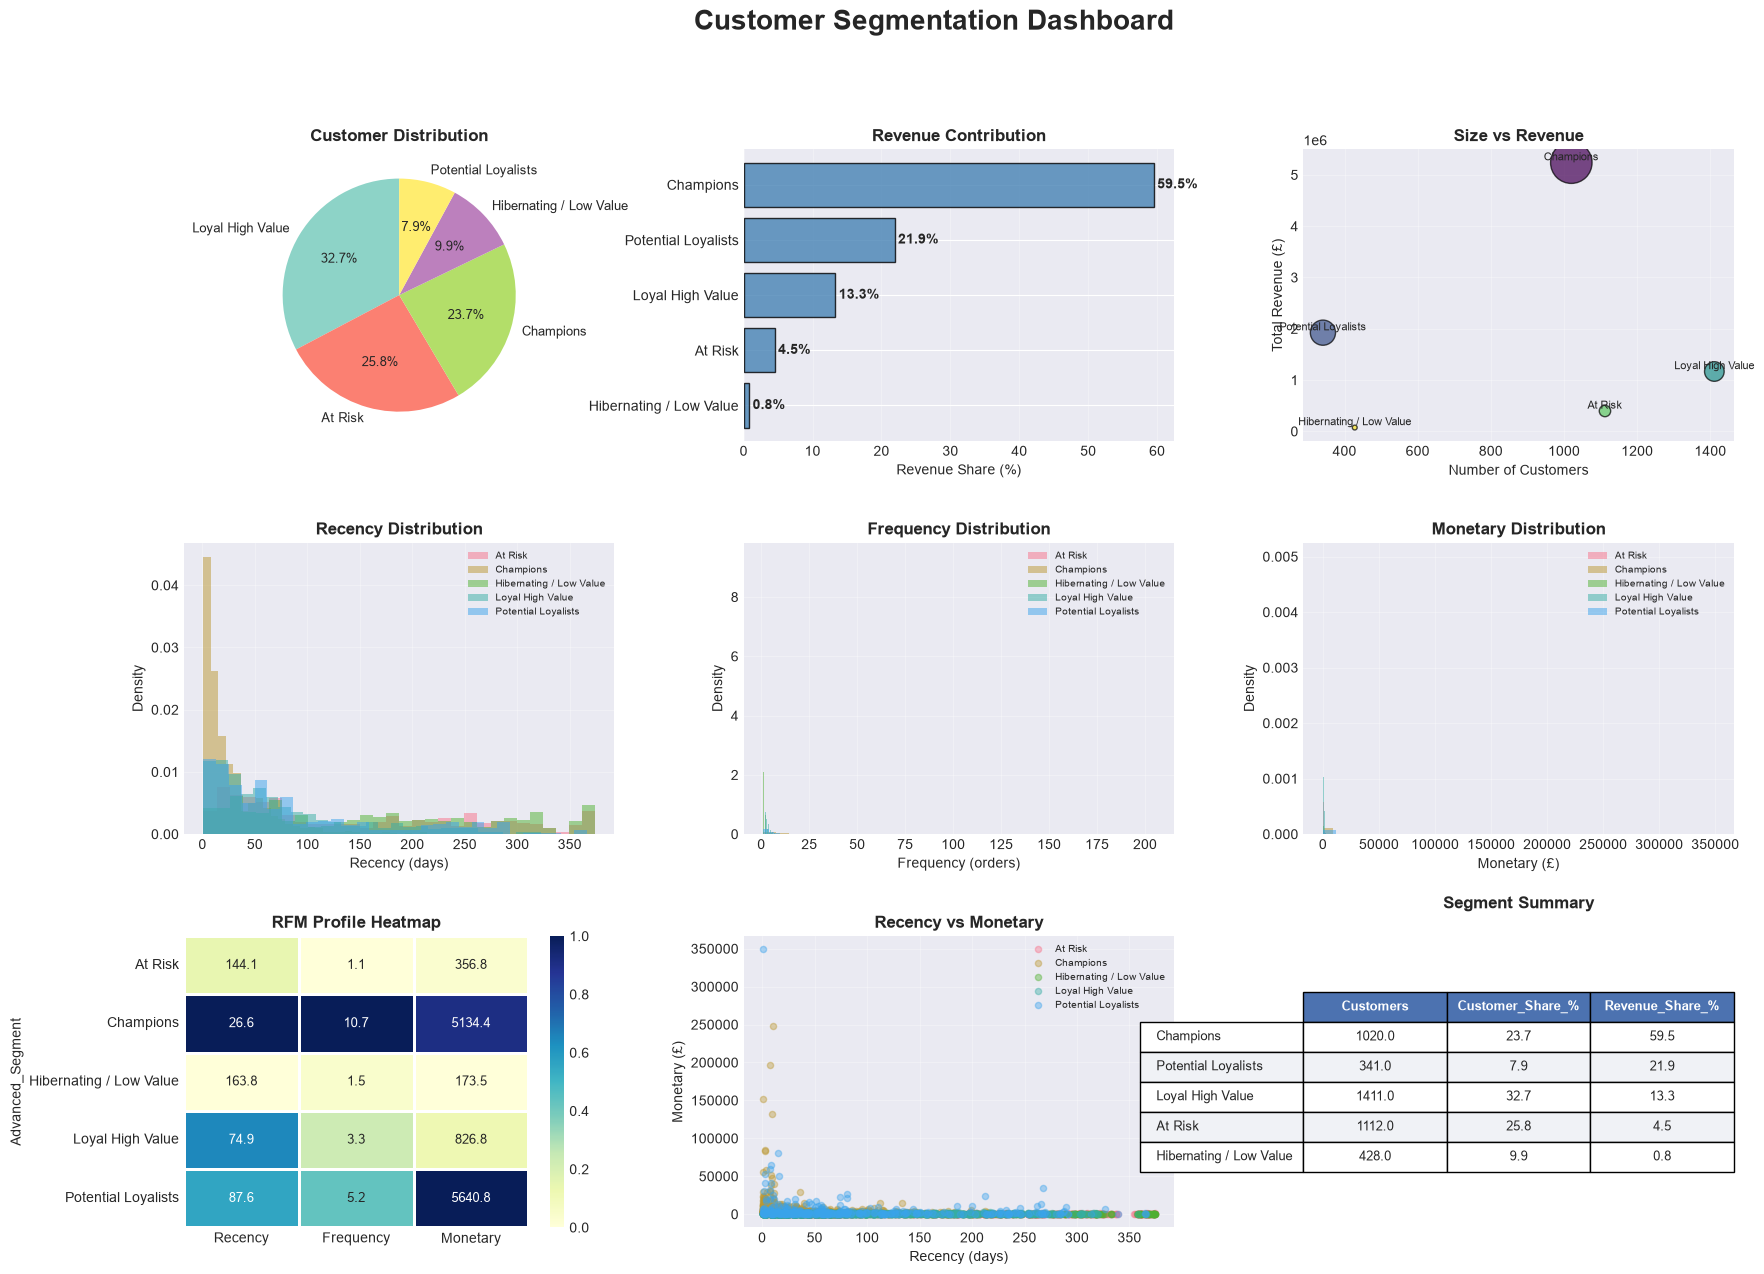

Saved: reports/figures/executive_dashboard.png


In [5]:
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Customer Segmentation Dashboard', fontsize=20, fontweight='bold', y=0.98)

gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1a. Segment pie chart
ax1 = fig.add_subplot(gs[0, 0])
seg_counts = df[segment_col].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(seg_counts)))
wedges, texts, autotexts = ax1.pie(
    seg_counts, labels=seg_counts.index, autopct='%1.1f%%',
    startangle=90, colors=colors, textprops={'fontsize': 9}
)
ax1.set_title('Customer Distribution', fontweight='bold', fontsize=12)

# 1b. Revenue share bar
ax2 = fig.add_subplot(gs[0, 1])
rev_sorted = seg_profile.sort_values('Revenue_Share_%', ascending=True)
bars = ax2.barh(rev_sorted.index, rev_sorted['Revenue_Share_%'], 
                color='steelblue', edgecolor='black', alpha=0.8)
for bar, val in zip(bars, rev_sorted['Revenue_Share_%']):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax2.set_xlabel('Revenue Share (%)')
ax2.set_title('Revenue Contribution', fontweight='bold', fontsize=12)
ax2.grid(axis='x', alpha=0.3)

# 1c. Customer count vs revenue scatter
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(seg_profile['Customers'], seg_profile['Total_Revenue'],
            s=seg_profile['Revenue_Share_%'] * 15, alpha=0.7,
            c=range(len(seg_profile)), cmap='viridis', edgecolors='black')
for seg, row in seg_profile.iterrows():
    ax3.annotate(seg, (row['Customers'], row['Total_Revenue']),
                 fontsize=8, ha='center', va='bottom')
ax3.set_xlabel('Number of Customers')
ax3.set_ylabel('Total Revenue (£)')
ax3.set_title('Size vs Revenue', fontweight='bold', fontsize=12)
ax3.grid(alpha=0.3)

# 2a. Recency distribution by segment
ax4 = fig.add_subplot(gs[1, 0])
for seg in sorted(df[segment_col].dropna().unique()):
    data = df[df[segment_col] == seg]['Recency']
    ax4.hist(data, bins=30, alpha=0.5, label=seg, density=True)
ax4.set_xlabel('Recency (days)')
ax4.set_ylabel('Density')
ax4.set_title('Recency Distribution', fontweight='bold', fontsize=12)
ax4.legend(fontsize=7)
ax4.grid(alpha=0.3)

# 2b. Frequency distribution by segment
ax5 = fig.add_subplot(gs[1, 1])
for seg in sorted(df[segment_col].dropna().unique()):
    data = df[df[segment_col] == seg]['Frequency']
    ax5.hist(data, bins=30, alpha=0.5, label=seg, density=True)
ax5.set_xlabel('Frequency (orders)')
ax5.set_ylabel('Density')
ax5.set_title('Frequency Distribution', fontweight='bold', fontsize=12)
ax5.legend(fontsize=7)
ax5.grid(alpha=0.3)

# 2c. Monetary distribution by segment
ax6 = fig.add_subplot(gs[1, 2])
for seg in sorted(df[segment_col].dropna().unique()):
    data = df[df[segment_col] == seg]['Monetary']
    ax6.hist(data, bins=30, alpha=0.5, label=seg, density=True)
ax6.set_xlabel('Monetary (£)')
ax6.set_ylabel('Density')
ax6.set_title('Monetary Distribution', fontweight='bold', fontsize=12)
ax6.legend(fontsize=7)
ax6.grid(alpha=0.3)

# 3a. RFM heatmap
ax7 = fig.add_subplot(gs[2, 0])
rfm_means = df.groupby(segment_col)[['Recency', 'Frequency', 'Monetary']].mean()
rfm_norm = (rfm_means - rfm_means.min()) / (rfm_means.max() - rfm_means.min())
if 'Recency' in rfm_norm.columns:
    rfm_norm['Recency'] = 1 - rfm_norm['Recency']
sns.heatmap(rfm_norm, annot=rfm_means.round(1), fmt='g', cmap='YlGnBu',
            ax=ax7, linewidths=2, annot_kws={'size': 9})
ax7.set_title('RFM Profile Heatmap', fontweight='bold', fontsize=12)

# 3b. Recency vs Monetary scatter
ax8 = fig.add_subplot(gs[2, 1])
for seg in sorted(df[segment_col].dropna().unique()):
    mask = df[segment_col] == seg
    ax8.scatter(df.loc[mask, 'Recency'], df.loc[mask, 'Monetary'],
                alpha=0.4, s=20, label=seg)
ax8.set_xlabel('Recency (days)')
ax8.set_ylabel('Monetary (£)')
ax8.set_title('Recency vs Monetary', fontweight='bold', fontsize=12)
ax8.legend(fontsize=7)
ax8.grid(alpha=0.3)

# 3c. Key stats table
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')
table_data = seg_profile[['Customers', 'Customer_Share_%', 'Revenue_Share_%']].round(1)
table_data['Customers'] = table_data['Customers'].astype(int)
table = ax9.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    rowLabels=table_data.index,
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#4C72B0')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#f0f2f6' if row % 2 == 0 else 'white')
ax9.set_title('Segment Summary', fontweight='bold', fontsize=12, pad=20)

plt.savefig('../reports/figures/executive_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: reports/figures/executive_dashboard.png")

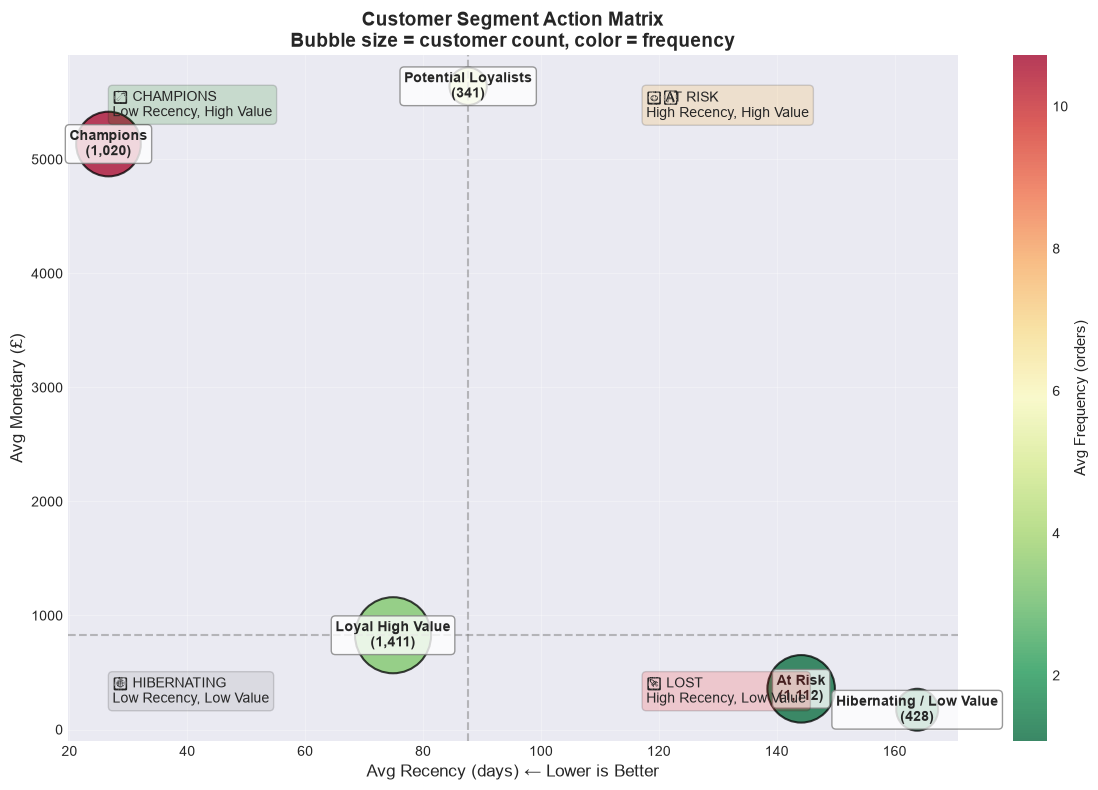

Saved: reports/figures/segment_action_matrix.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 8))

seg_means = df.groupby(segment_col).agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Customer ID': 'count',
}).rename(columns={'Customer ID': 'Count'})

sizes = seg_means['Count'] / seg_means['Count'].max() * 3000
scatter = ax.scatter(
    seg_means['Recency'],
    seg_means['Monetary'],
    s=sizes,
    c=seg_means['Frequency'],
    cmap='RdYlGn_r',
    alpha=0.75,
    edgecolors='black',
    linewidth=1.5,
)

for seg, row in seg_means.iterrows():
    ax.annotate(
        f"{seg}\n({int(row['Count']):,})",
        (row['Recency'], row['Monetary']),
        fontsize=10, fontweight='bold',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                  edgecolor='gray', alpha=0.8),
    )

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Avg Frequency (orders)', fontsize=11)

# Quadrant lines
ax.axvline(seg_means['Recency'].median(), color='gray', linestyle='--', alpha=0.5)
ax.axhline(seg_means['Monetary'].median(), color='gray', linestyle='--', alpha=0.5)

# Quadrant labels
ax.text(0.05, 0.95, '⭐ CHAMPIONS\nLow Recency, High Value', 
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(facecolor='green', alpha=0.15, boxstyle='round'))
ax.text(0.65, 0.95, '⚠️ AT RISK\nHigh Recency, High Value', 
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(facecolor='orange', alpha=0.15, boxstyle='round'))
ax.text(0.05, 0.05, '💤 HIBERNATING\nLow Recency, Low Value', 
        transform=ax.transAxes, fontsize=10, va='bottom',
        bbox=dict(facecolor='gray', alpha=0.15, boxstyle='round'))
ax.text(0.65, 0.05, '🚨 LOST\nHigh Recency, Low Value', 
        transform=ax.transAxes, fontsize=10, va='bottom',
        bbox=dict(facecolor='red', alpha=0.15, boxstyle='round'))

ax.set_xlabel('Avg Recency (days) ← Lower is Better', fontsize=12)
ax.set_ylabel('Avg Monetary (£)', fontsize=12)
ax.set_title('Customer Segment Action Matrix\nBubble size = customer count, color = frequency',
             fontweight='bold', fontsize=14)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/segment_action_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: reports/figures/segment_action_matrix.png")

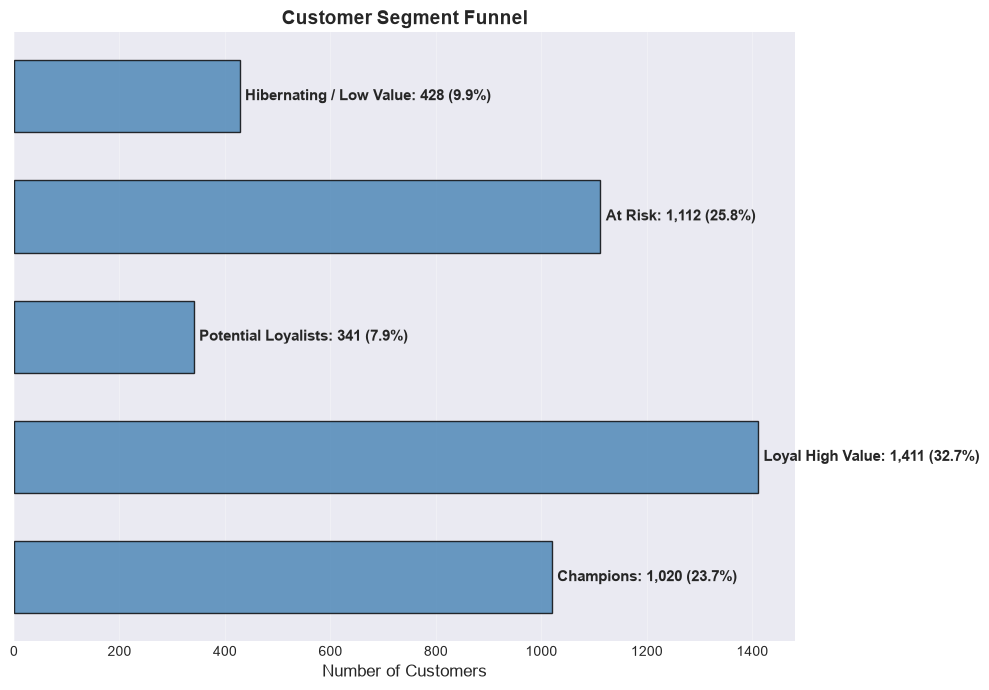

Saved: reports/figures/segment_funnel.png


In [7]:
if 'Avg_Recency' in seg_profile.columns:
    ordered = seg_profile.sort_values('Avg_Recency', ascending=True)
else:
    ordered = seg_profile.sort_values('Total_Revenue', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))

y_pos = range(len(ordered))
bars = ax.barh(y_pos, ordered['Customers'], color='steelblue', 
               edgecolor='black', alpha=0.8, height=0.6)

for i, (seg, row) in enumerate(ordered.iterrows()):
    ax.text(row['Customers'] + 10, i, 
            f"{seg}: {int(row['Customers']):,} ({row['Customer_Share_%']:.1f}%)",
            va='center', fontsize=11, fontweight='bold')

ax.set_yticks([])
ax.set_xlabel('Number of Customers', fontsize=12)
ax.set_title('Customer Segment Funnel', fontweight='bold', fontsize=14)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/segment_funnel.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: reports/figures/segment_funnel.png")

In [14]:
report_html = f"""<!DOCTYPE html>
<html>
<head>
    <title>Customer Segmentation Report</title>
    <style>
        body {{ font-family: 'Segoe UI', Arial, sans-serif; margin: 40px; 
               background: #f5f7fa; color: #333; }}
        .header {{ background: linear-gradient(135deg, #667eea, #764ba2); 
                   color: white; padding: 30px; border-radius: 12px; 
                   margin-bottom: 30px; }}
        .header h1 {{ margin: 0; }}
        .kpi-row {{ display: flex; gap: 20px; margin-bottom: 30px; }}
        .kpi {{ background: white; padding: 20px; border-radius: 8px; 
                flex: 1; text-align: center; box-shadow: 0 2px 8px rgba(0,0,0,0.1); }}
        .kpi h2 {{ color: #667eea; margin: 0; }}
        .kpi p {{ color: #666; margin: 5px 0 0; }}
        .section {{ background: white; padding: 25px; border-radius: 8px; 
                    margin-bottom: 20px; box-shadow: 0 2px 8px rgba(0,0,0,0.1); }}
        table {{ width: 100%; border-collapse: collapse; margin-top: 15px; }}
        th {{ background: #667eea; color: white; padding: 12px; text-align: left; }}
        td {{ padding: 10px 12px; border-bottom: 1px solid #eee; }}
        tr:hover {{ background: #f0f2f6; }}
        img {{ max-width: 100%; border-radius: 8px; margin: 15px 0; }}
    </style>
</head>
<body>
    <div class="header">
        <h1>🎯 Customer Segmentation Report</h1>
        <p>Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}</p>
    </div>
    
    <div class="kpi-row">
        <div class="kpi"><h2>{total_customers:,}</h2><p>Total Customers</p></div>
        <div class="kpi"><h2>£{total_revenue:,.0f}</h2><p>Total Revenue</p></div>
        <div class="kpi"><h2>£{avg_order:,.0f}</h2><p>Avg Revenue/Customer</p></div>
        <div class="kpi"><h2>{n_segments}</h2><p>Segments</p></div>
    </div>
    
    <div class="section">
        <h2>📊 Executive Dashboard</h2>
        <img src="figures/executive_dashboard.png" alt="Dashboard">
    </div>
    
    <div class="section">
        <h2>🎯 Action Matrix</h2>
        <img src="figures/segment_action_matrix.png" alt="Action Matrix">
    </div>
    
    <div class="section">
        <h2>📋 Segment Profiles</h2>
        <table>
            <tr>
                <th>Segment</th><th>Customers</th><th>Share %</th>
                <th>Avg Recency</th><th>Avg Frequency</th>
                <th>Avg Monetary</th><th>Total Revenue</th><th>Rev Share %</th>
            </tr>
"""

for seg, row in seg_profile.iterrows():
    report_html += f"""
            <tr>
                <td><b>{seg}</b></td>
                <td>{int(row['Customers']):,}</td>
                <td>{row['Customer_Share_%']:.1f}%</td>
                <td>{row['Avg_Recency']:.0f} days</td>
                <td>{row['Avg_Frequency']:.1f}</td>
                <td>£{row['Avg_Monetary']:,.2f}</td>
                <td>£{row['Total_Revenue']:,.0f}</td>
                <td>{row['Revenue_Share_%']:.1f}%</td>
            </tr>"""

report_html += """
        </table>
    </div>
    
    <div class="section">
        <h2>📈 Segment Funnel</h2>
        <img src="figures/segment_funnel.png" alt="Funnel">
    </div>
</body>
</html>"""

from pathlib import Path

Path('../reports').mkdir(parents=True, exist_ok=True)

with open('../reports/customer_segmentation_report.html', 'w', encoding='utf-8') as f:
    f.write(report_html)

print("Saved: reports/customer_segmentation_report.html")

Saved: reports/customer_segmentation_report.html


In [15]:
final_report = {
    'report_date': pd.Timestamp.now().isoformat(),
    'data_source': 'advanced' if 'Advanced' in segment_col else 'basic',
    'key_metrics': {
        'total_customers': int(total_customers),
        'total_revenue': float(total_revenue),
        'avg_revenue_per_customer': float(avg_order),
        'avg_frequency': float(avg_freq),
        'avg_recency_days': float(avg_recency),
        'num_segments': int(n_segments),
    },
    'segments': {}
}

for seg, row in seg_profile.iterrows():
    final_report['segments'][seg] = {
        'customers': int(row['Customers']),
        'customer_share_pct': float(row['Customer_Share_%']),
        'avg_recency': float(row['Avg_Recency']),
        'avg_frequency': float(row['Avg_Frequency']),
        'avg_monetary': float(row['Avg_Monetary']),
        'total_revenue': float(row['Total_Revenue']),
        'revenue_share_pct': float(row['Revenue_Share_%']),
    }

with open('../reports/final_segmentation_report.json', 'w') as f:
    json.dump(final_report, f, indent=4)

print("Saved: reports/final_segmentation_report.json")

Saved: reports/final_segmentation_report.json


In [16]:
print("=" * 60)
print("DASHBOARD & REPORTING COMPLETE")
print("=" * 60)

print(f"\n📁 Files Created:")
print(f"   📊 reports/figures/executive_dashboard.png")
print(f"   🎯 reports/figures/segment_action_matrix.png")
print(f"   📈 reports/figures/segment_funnel.png")
print(f"   🌐 reports/customer_segmentation_report.html")
print(f"   📄 reports/final_segmentation_report.json")

print(f"\n🚀 To launch the interactive dashboard:")
print(f"   streamlit run src/dashboard/app.py")

print(f"\n📊 Dashboard Features:")
print(f"   ✅ Executive Overview with KPIs")
print(f"   ✅ Interactive segment filtering")
print(f"   ✅ RFM radar charts & distributions")
print(f"   ✅ Segment deep dive explorer")
print(f"   ✅ Revenue analysis & breakdowns")
print(f"   ✅ Customer search & top customers")
print(f"   ✅ Business recommendations")

print("\n" + "=" * 60)

DASHBOARD & REPORTING COMPLETE

📁 Files Created:
   📊 reports/figures/executive_dashboard.png
   🎯 reports/figures/segment_action_matrix.png
   📈 reports/figures/segment_funnel.png
   🌐 reports/customer_segmentation_report.html
   📄 reports/final_segmentation_report.json

🚀 To launch the interactive dashboard:
   streamlit run src/dashboard/app.py

📊 Dashboard Features:
   ✅ Executive Overview with KPIs
   ✅ Interactive segment filtering
   ✅ RFM radar charts & distributions
   ✅ Segment deep dive explorer
   ✅ Revenue analysis & breakdowns
   ✅ Customer search & top customers
   ✅ Business recommendations

